<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libreria SDV
*Autor: Alumno*
*Fecha: 04 de junio*

In [5]:
pip install sdv sdmetrics

In [6]:
import pandas as pd
import numpy as np
import random

In [7]:
import sdv
import sdmetrics

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [8]:
from sdmetrics.reports.single_table import QualityReport

In [9]:
print ("SDV",sdv.__version__)
print ("SDMetrics",sdmetrics.__version__)

SDV 1.37.0
SDMetrics 0.28.0


In [10]:
#Creamos un Dataset (original) que servira como una fuente para crear los datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1,2,3,4,5,6,7,8,9,10],
        "edad": [23,33,43,28,53,56,43,56,65,40],
        "ingreso_mensual": [25000,15000,20000,10000,5000,17000,30000,12000,35000,7500],
        "ciudad": ["Veracruz","Cordoba","Paso del Macho","Amatlan","Fortin","Cuitlahuac","Yanga","Cordoba","Orizaba","Cuitlahuac"],
    }
)

In [11]:
dfClientes.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,25000,Veracruz
1,2,33,15000,Cordoba
2,3,43,20000,Paso del Macho
3,4,28,10000,Amatlan
4,5,53,5000,Fortin


In [12]:
#Definir metadatos
metadata = SingleTableMetadata()

In [13]:
metadata.detect_from_dataframe(
    data=dfClientes
    )

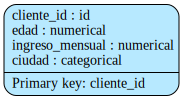

In [14]:
metadata.visualize()

In [15]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

In [16]:
#Guardamos en json
metadata.save_to_json(
    "dfClientes_metadata.json"
)

In [17]:
#Entrenamos el modelo para generar los datos sinteticos
synthesizer = GaussianCopulaSynthesizer(
    metadata
)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
